# Netflix data set 



In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [107]:
# import the data

df = pd.read_csv('netflix_titles.csv')


In [108]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [109]:
df.shape

(8807, 12)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [111]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [112]:
df.describe(include = 'object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


# Data cleaning

In [113]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [114]:
# Director, cast, country, date_added , rating, duration, have missing values 

df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [115]:
# We have made an copy of original data 

df_copy = df.copy()


In [116]:
df_copy.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


for director and cast have very large missing values we cant use mode in that it will create data fabric not clean 
insted of it will fill with unknown values.

In [117]:
df_copy['director'].isnull().sum()

np.int64(2634)

In [118]:
df_copy['cast'].isnull().sum()

np.int64(825)

In [119]:
df_copy['director'] = df_copy['director'].replace(np.nan, 'unknown')


In [120]:
df_copy['cast'] = df_copy['cast'].fillna('Unknown')

for the country column if missing values are very less we can use mode on it to fill NAN
but the values are more missing we use fillna to fill with 'unknown'

In [121]:
df_copy['country'] = df_copy['country'].fillna('unknown')

In [122]:
df_copy.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


date_added : have missing values but also these are not in formate we have to breaks them into month , date, year 
using .to_datetime()

In [123]:
df_copy['date_added'].unique()

array(['September 25, 2021', 'September 24, 2021', 'September 23, 2021',
       ..., 'December 6, 2018', 'March 9, 2016', 'January 11, 2020'],
      dtype=object)

In [124]:
df_copy['date_added'].isnull().sum()

np.int64(10)

use errors = 'coerce' when this gives u some invalid errors while converting with it into datetime()

doing this when we separte the date , day , month we see that it shows the values in float beacuse of the Nat: not a time basically in date time column

so thats why covert float to integer by using .astype('Int64') 

use pandas nullble Int64 because of Nat present 

In [125]:
df_copy["date_added"] = pd.to_datetime(df_copy["date_added"], errors = 'coerce')

In [126]:


df_copy['year'] = df_copy['date_added'].dt.year
df_copy['month'] = df_copy['date_added'].dt.month
df_copy['day'] = df_copy['date_added'].dt.day

In [127]:
df_copy['day'].unique()

array([25., 24., 23., 22., 21., 20., 19., 17., 16., 15., 14., 11., 10.,
        9.,  8.,  7.,  6.,  5.,  4.,  3.,  2.,  1., 31., 29., 28., 27.,
       26., 18., 13., 12., 30., nan])

In [128]:
df_copy["year"] = df_copy["year"].astype("Int64")

In [129]:
df_copy['day'] = df_copy['day'].astype("Int64")
df_copy['month'] = df_copy['month'].astype('Int64')

we have seen the dat , month , and  year have lot of missing values dont fill them stay as it is 

In [130]:
df_copy.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           4
duration         3
listed_in        0
description      0
year            98
month           98
day             98
dtype: int64

# Rating 

In rating col there are some 'min' values also 

this min values are by mistakenly shift to rating col 

shift the min values into duration column

In [131]:
df_copy['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [132]:
df_copy['duration'].unique

<bound method Series.unique of 0          90 min
1       2 Seasons
2        1 Season
3        1 Season
4       2 Seasons
          ...    
8802      158 min
8803    2 Seasons
8804       88 min
8805       88 min
8806      111 min
Name: duration, Length: 8807, dtype: object>

str.contains 'min' in rating column then it gives True if present in particular row

it gives False if not present in row 

na = False use for if null value there dont give error

Now shift all this min value to duration columns wherever the row has Nan  using Loc[]

.loc[] lets us say:

Go to these specific column and update this specific row

In [133]:
min_val = df_copy["rating"].str.contains("min", na=False)

In [134]:
min_val.unique()   

array([False,  True])

copy all the duration_value if its True and shift to duration column

and remove it from rating 

In [135]:
# "Go to the rows where min_val is True, take the values from the rating column, and put them into the duration column."

df_copy.loc[min_val, "duration"] = df_copy.loc[min_val, "rating"]


In [136]:
 # For those same rows, replace the incorrect rating with a missing value.
 df_copy.loc[min_val, "rating"] = pd.NA 

In [137]:
df_copy['rating'].unique()    # here the <NA> and nan both are missing values have same meaning

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', <NA>, 'NR', nan, 'TV-Y7-FV', 'UR'],
      dtype=object)

Duration :
now we shifted all the min values from rating to duration col using .Loc[]

but in duration column some values are min and some season

Movie : min
Tv show : seasons

leave the col as it is now we can do it after if want using feature engineering

In [138]:
df_copy['duration'].unique

<bound method Series.unique of 0          90 min
1       2 Seasons
2        1 Season
3        1 Season
4       2 Seasons
          ...    
8802      158 min
8803    2 Seasons
8804       88 min
8805       88 min
8806      111 min
Name: duration, Length: 8807, dtype: object>

In [139]:
df_copy.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           7
duration         0
listed_in        0
description      0
year            98
month           98
day             98
dtype: int64

In [140]:
df_copy['release_year'].unique

<bound method Series.unique of 0       2020
1       2021
2       2021
3       2021
4       2021
        ... 
8802    2007
8803    2018
8804    2009
8805    2006
8806    2015
Name: release_year, Length: 8807, dtype: int64>

In [141]:
df_copy['listed_in'].unique

<bound method Series.unique of 0                                           Documentaries
1         International TV Shows, TV Dramas, TV Mysteries
2       Crime TV Shows, International TV Shows, TV Act...
3                                  Docuseries, Reality TV
4       International TV Shows, Romantic TV Shows, TV ...
                              ...                        
8802                       Cult Movies, Dramas, Thrillers
8803               Kids' TV, Korean TV Shows, TV Comedies
8804                              Comedies, Horror Movies
8805                   Children & Family Movies, Comedies
8806       Dramas, International Movies, Music & Musicals
Name: listed_in, Length: 8807, dtype: object>

In [142]:
df_copy['description'].unique

<bound method Series.unique of 0       As her father nears the end of his life, filmm...
1       After crossing paths at a party, a Cape Town t...
2       To protect his family from a powerful drug lor...
3       Feuds, flirtations and toilet talk go down amo...
4       In a city of coaching centers known to train I...
                              ...                        
8802    A political cartoonist, a crime reporter and a...
8803    While living alone in a spooky town, a young g...
8804    Looking to survive in a world taken over by zo...
8805    Dragged from civilian life, a former superhero...
8806    A scrappy but poor boy worms his way into a ty...
Name: description, Length: 8807, dtype: object>

In [143]:
df_copy['rating'] = df_copy['rating'].fillna('unknown')

In [144]:
df_copy.isnull().sum()  

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
year            98
month           98
day             98
dtype: int64

We have handle all the null and inconsistent data till now in all columns

now handel duplicate data on column which strongly not recommended duplicates in it

show_id : is act as unique id duplication is not possible

but all columns rather then show_id duplication can be allowd

In [145]:
df_copy[df_copy.duplicated('show_id')].shape     # no duplicate value present in showID

(0, 15)

In [146]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year          8709 non-null   Int64         
 13  month         8709 non-null   Int64         
 14  day           8709 non-null   Int64         
dtypes: Int64(3), datetime64[ns](1), int64(

# EDA

In [147]:
df_copy.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,month,day
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,25
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,24


divides the columns into numerical and categorical features 

In [148]:
numeric_features = [feature for feature in df_copy.columns if df_copy[feature].dtype != 'O']   # not equal to objects 

categorical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype == 'O'] # equal to objects


In [149]:
# print all columns

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))       # formate put all the values in {}

print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 5 numerical features : ['date_added', 'release_year', 'year', 'month', 'day']

We have 10 categorical features : ['show_id', 'type', 'title', 'director', 'cast', 'country', 'rating', 'duration', 'listed_in', 'description']


In [150]:
#movie vs tv show distribution
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [151]:
plt.figure(figsize=(6,4))

sns.countplot(data=df_copy, x="type")

plt.title("Distribution of Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

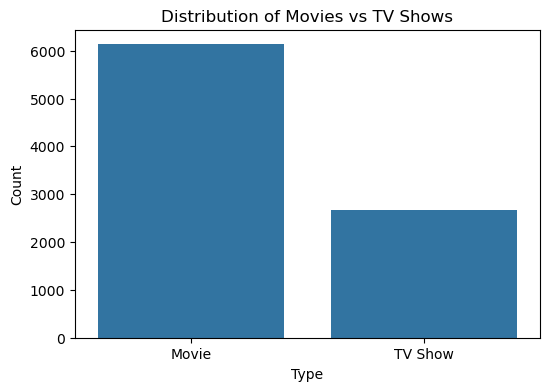

In [152]:
plt.show()

# observation :
From this we observe the movie have large number of distributions as compare to tv show

In [153]:
## most common rating

plt.figure(figsize=(10,8))
sns.countplot(data = df_copy, y = "rating", color = 'teal')
plt.title('Most Common Ratings')


Text(0.5, 1.0, 'Most Common Ratings')

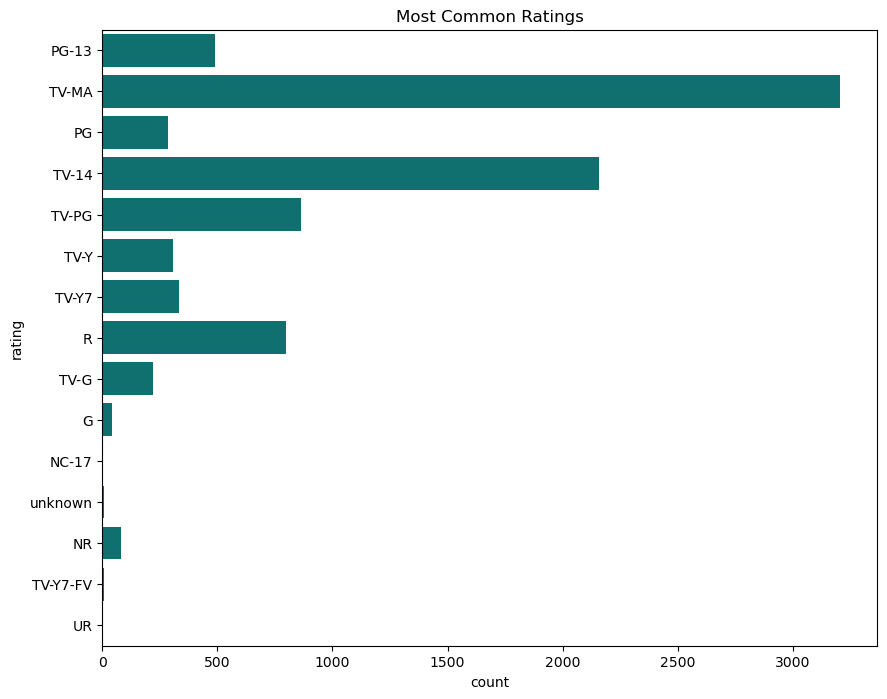

In [154]:
plt.show()

# observation :
Based on observation most common rating is TV-MA
then TV-14
then Tv-PG
very less rating is : G


In [155]:
# top 10 countries

top_countries = df_copy["country"].value_counts().head(10)


In [156]:
top_countries

country
United States     2818
India              972
unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

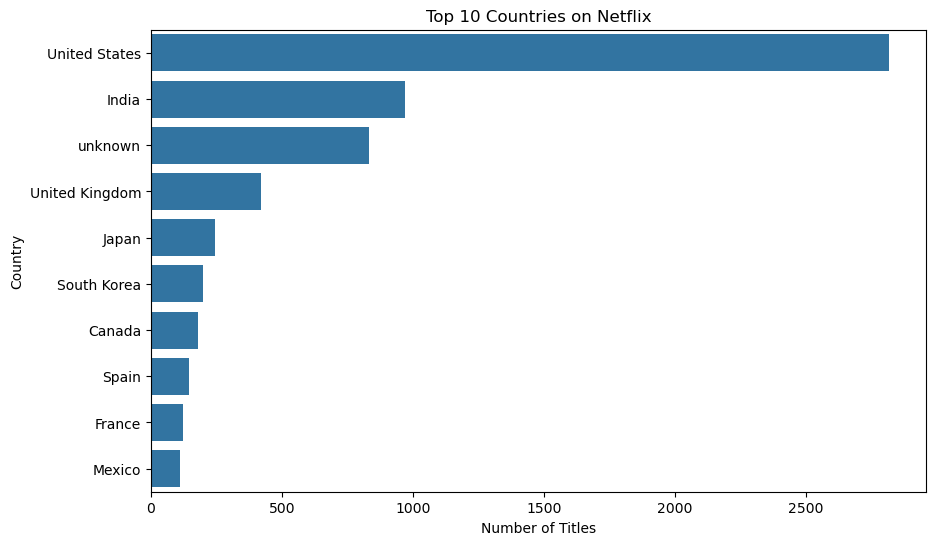

In [157]:

plt.figure(figsize=(10,6))

sns.barplot(x=top_countries.values, y=top_countries.index)   # values : count of tv shows and movies , index: country name

plt.title("Top 10 Countries on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

# Observation :
united states watches most no of tv shows and movies 
india is the second number to watch movies
Unknown are basically null values 
from japan onwards the countries are watch very low movies

In [158]:
# how has the netflix content grown over the year

#values are title 
# and index are year

year_count = df_copy["release_year"].value_counts().sort_index()

In [159]:
year_count

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

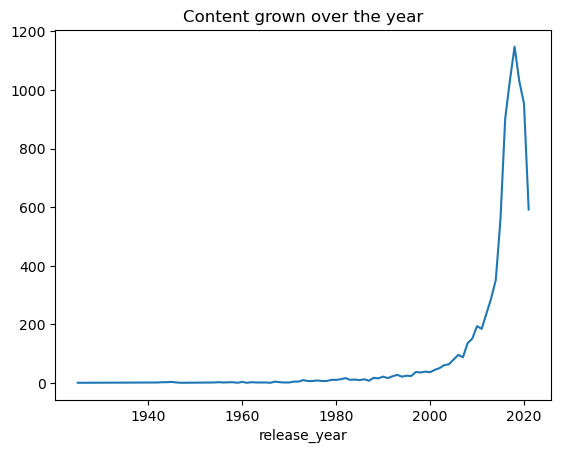

In [160]:
sns.lineplot(x = year_count.index, y = year_count.values)
plt.title('Content grown over the year')
plt.show()


# Observation:
Netflix content remained very low before the 2000
The number of titles started increasing rapidly after around 2010
The highest number of titles was released around 2018–2019
but after that peak there is sudden decline changes are there

In [161]:
# how did movies vs tv show changes over year
movie_tv_year = df_copy.groupby(["release_year", "type"]).size().unstack()  # unstack helps to covert data into tabular formate

In [162]:
movie_tv_year

type,Movie,TV Show
release_year,,
1925,NaN,1.0
1942,2.0,NaN
1943,3.0,NaN
1944,3.0,NaN
1945,3.0,1.0
...,...,...
2017,767.0,265.0
2018,767.0,380.0
2019,633.0,397.0


In [163]:
movie_tv_year.plot(kind="line") 
plt.grid(axis="x", linestyle="--", alpha=0.4)  # x year , y = count

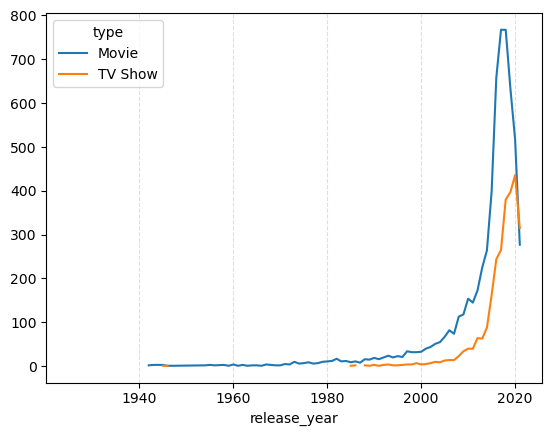

In [164]:
plt.show()

from 2000 the movie increses rapidly 

Tv shows are very low before 2000 and it shows the sudden changes after 2000

but as comapre to movie, has very low counts of the title 



In [165]:
# what are the most top genere?

# there are 2 to 3 genere at once split them first makes them into list 

df_copy["listed_in"] = df_copy["listed_in"].str.split(", ")

In [166]:
df_copy = df_copy.explode("listed_in")  # explode() It takes every item in the list and creates a new row.

In [167]:
top_genres = df_copy["listed_in"].value_counts().head(10)

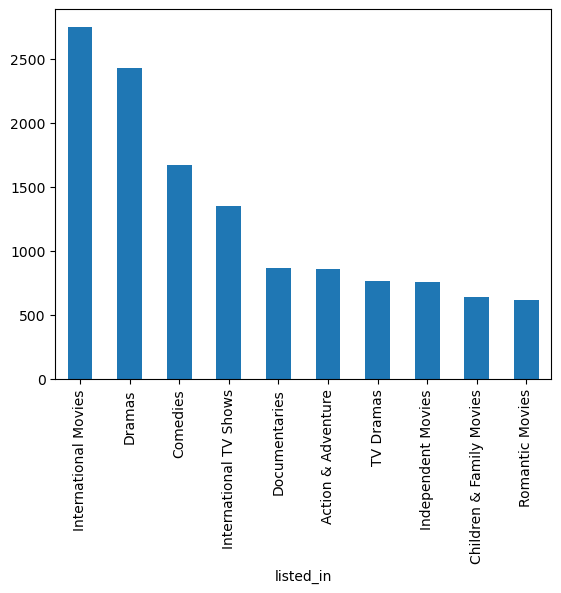

<Figure size 1000x2000 with 0 Axes>

In [168]:
top_genres.plot(y = 'listed_in', kind = 'bar')
plt.figure(figsize=(10,20))

plt.show()

# Observation:
International Movies is the most common genre on Netflix (~2750 titles)

Dramas is the second most common genre.

Comedies ranks third, showing that entertainment and light-hearted content are also a major part of Netflix's library.

Genres like Documentaries, Action & Adventure, TV Dramas, Independent Movies, and Children & Family Movies have comparatively fewer titles.


#  feature engineering

duration was split into duration_value (numeric) and duration_unit (minutes/seasons) 

to enable numerical analysis of movie durations and TV show seasons.

In [169]:
df_copy['duration_value'] = df_copy['duration'].str.split(' ').str[0]
df_copy['duration_unit']  = df_copy['duration'].str.split(' ').str[1]


In [170]:
# covert duration value into int 
df_copy['duration_value'] = df_copy['duration_value'].astype(int)

In [171]:
df_copy['duration_value'].isnull().sum()

np.int64(0)

In [172]:
df_copy['duration_unit'].isnull().sum()

np.int64(0)

In [173]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19323 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         19323 non-null  object        
 1   type            19323 non-null  object        
 2   title           19323 non-null  object        
 3   director        19323 non-null  object        
 4   cast            19323 non-null  object        
 5   country         19323 non-null  object        
 6   date_added      19120 non-null  datetime64[ns]
 7   release_year    19323 non-null  int64         
 8   rating          19323 non-null  object        
 9   duration        19323 non-null  object        
 10  listed_in       19323 non-null  object        
 11  description     19323 non-null  object        
 12  year            19120 non-null  Int64         
 13  month           19120 non-null  Int64         
 14  day             19120 non-null  Int64         
 15  duration

In [174]:
# What is the distribution of movie durations on Netflix?

dur_min = df_copy[df_copy['duration_unit'] == 'min']

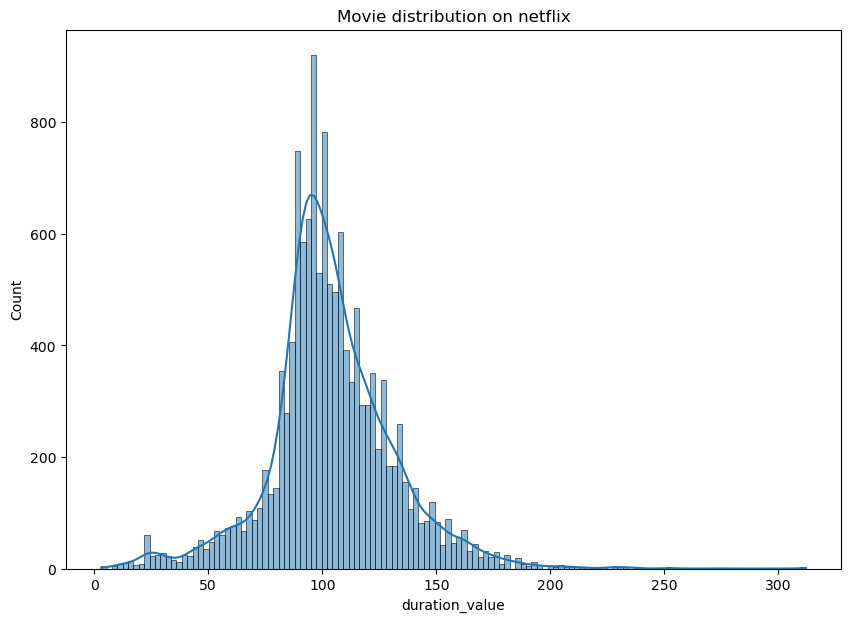

In [175]:
plt.figure(figsize = (10,7))

sns.histplot(x = 'duration_value', data = dur_min, kde= True)
plt.title('Movie distribution on netflix')

plt.show()

# Observation :
 
x axis : duration_value represent the movie_duration in minutes.
y axis : duration_unit represents count How many movies fall into that duration range.
Most Netflix movies are between 90 and 110 minutes.
Only a small number of movies have very long durations, resulting in a right-skewed distribution

# Insights / Conclusion


• Movies account for the majority of Netflix's content.

• TV-MA is the most common content rating.

• The United States contributes the largest number of titles.

• Netflix experienced rapid content growth after 2015.

• International Movies and Dramas are the most frequent genres.

• Most movies have durations between 90–110 minutes.